<h2>Task 1 - Data extraction and initial analysis. <h2>

In [1]:
import pandas as pd
import numpy as np 
import polars as pl 
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

<h2>Data Extraction / Preprocessing:</h2>
<table>Navigate to the SEC's EDGAR database:

1. **Microsoft**
2. **Tesla**
3. **Apple**

Manual extraction:
</table>
For each company, find the 10-K filings for the last three fiscal years.
Extract the following financial figures: Total Revenue, Net Income, Total Assets, Total Liabilities, and Cash Flow from Operating Activities.


In [2]:
data  = pd.read_csv('bcgx_financial_data_2020_2025.csv')

data.head()

,Company,Fiscal Year,Total Revenue,Net Income,Total Assets,Total Liabilities,Cash Flow from Operating Activities
0,Amazon,2020,232.89,10.07,162.65,227.79,30.72
1,Amazon,2021,280.52,11.59,225.25,282.30,38.51
2,Amazon,2022,386.06,21.33,321.19,316.63,66.06
3,Amazon,2023,469.82,33.36,420.55,325.98,46.33
4,Amazon,2024,513.98,-2.72,462.68,368.64,46.75


In [3]:
data.Company.value_counts()

Company
Amazon       6
Apple        6
Google       6
Microsoft    6
Tesla        6
Name: count, dtype: int64

In [4]:
target_companies = ['Apple', 'Microsoft', 'Tesla']

df = data[data['Company'].isin(target_companies)]
df.reset_index(drop=True, inplace=True)


<h2>Step 2: Preparing your Jupyter Notebook environment</h2>


In [9]:
cols_to_grow = {
    'Total Revenue': 'Revenue Growth (%)',
    'Net Income': 'Net Income Growth (%)',
    'Total Assets': 'Asset Growth (%)',
    'Cash Flow from Operating Activities': 'Cash Flow Growth (%)',
    'Total Liabilities': 'Liabilities Growth (%)'
}

# Ensure df is a standalone copy
df = df.copy()

for original, new in cols_to_grow.items():
    df[new] = df.groupby('Company')[original].pct_change() * 100

In [10]:
df.head()

,Company,Fiscal Year,Total Revenue,Net Income,Total Assets,Total Liabilities,Cash Flow from Operating Activities,Revenue Growth (%),Net Income Growth (%),Asset Growth (%),Cash Flow Growth (%),Liabilities Growth (%)
0,Apple,2020,265.60,59.53,338.52,248.03,77.43,NaN,NaN,NaN,NaN,NaN
1,Apple,2021,260.17,55.26,323.89,258.55,69.39,-2.044428,-7.172854,-4.321754,-10.383572,4.241422
2,Apple,2022,274.51,57.41,351.00,287.91,80.67,5.511781,3.890699,8.370126,16.255945,11.355637
3,Apple,2023,365.82,94.68,352.75,302.08,104.04,33.262905,64.919004,0.498575,28.969877,4.921677
4,Apple,2024,394.33,99.80,352.58,290.44,122.15,7.793450,5.407689,-0.048193,17.406767,-3.853284


In [12]:
summary = df.groupby('Company').agg({
    'Revenue Growth (%)': 'mean',
    'Net Income Growth (%)': 'mean',
    'Asset Growth (%)': 'mean',
    'Liabilities Growth (%)': 'mean',
    'Cash Flow Growth (%)': 'mean'
}).reset_index()

print(summary.to_string(index=False))

  Company  Revenue Growth (%)  Net Income Growth (%)  Asset Growth (%)  Liabilities Growth (%)  Cash Flow Growth (%)
    Apple            8.344805              12.847785          1.603137                4.544356              8.548862
Microsoft           14.008508              41.245006         12.493304                5.945292             15.212069
    Tesla           36.729142             123.532764         29.528076               13.157246             54.693986


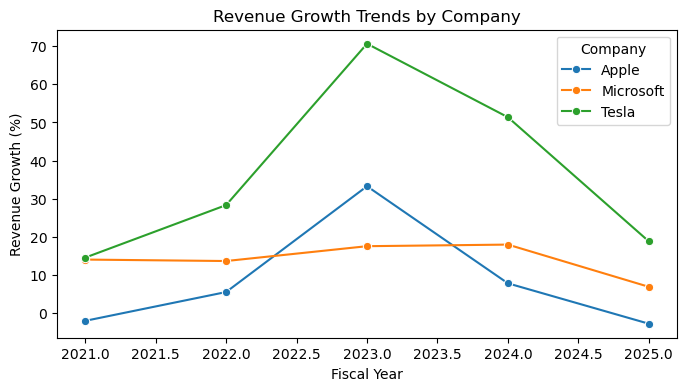

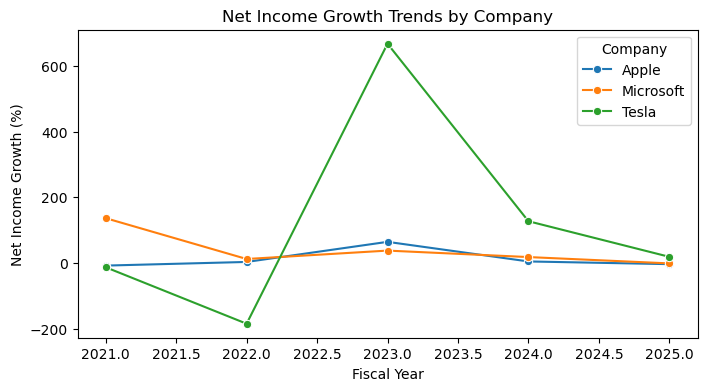

In [15]:
# Plotting revenue growth for each company
plt.figure(figsize=(8, 4))
sns.lineplot(data=df.assign(Year_Str=df['Fiscal Year'].astype(str)), x='Fiscal Year', y='Revenue Growth (%)', hue='Company', marker='o')
plt.title('Revenue Growth Trends by Company')
plt.xlabel('Fiscal Year')
plt.ylabel('Revenue Growth (%)')
plt.legend(title='Company')
plt.show()

# Plotting net income growth for each company
plt.figure(figsize=(8, 4))
sns.lineplot(data=df.assign(Year_Str=df['Fiscal Year'].astype(str)), x='Fiscal Year', y='Net Income Growth (%)', hue='Company', marker='o')
plt.title('Net Income Growth Trends by Company')
plt.xlabel('Fiscal Year')
plt.ylabel('Net Income Growth (%)')
plt.legend(title='Company')
plt.show()

In [20]:
for company in df['Company'].unique():
    company_data = df[df['Company'] == company]
    corr_matrix = company_data[['Total Revenue', 'Net Income', 'Total Assets','Total Liabilities', 'Cash Flow from Operating Activities']].corr()
    print(f"Correlation Matrix for {company}\n")
    print(corr_matrix.to_string())
    print("\n")

Correlation Matrix for Apple

                                     Total Revenue  Net Income  Total Assets  Total Liabilities  Cash Flow from Operating Activities
Total Revenue                             1.000000    0.994578      0.769993           0.808088                             0.982692
Net Income                                0.994578    1.000000      0.746574           0.781321                             0.968852
Total Assets                              0.769993    0.746574      1.000000           0.868778                             0.779637
Total Liabilities                         0.808088    0.781321      0.868778           1.000000                             0.761578
Cash Flow from Operating Activities       0.982692    0.968852      0.779637           0.761578                             1.000000


Correlation Matrix for Microsoft

                                     Total Revenue  Net Income  Total Assets  Total Liabilities  Cash Flow from Operating Activities
Tot

<h2>Summary:</h2>

**<h3>TESLA:</h3>**

1. **Triple-Digit Profit Growth**: While Revenue grew <u>*36.7%*</u>, Net Income skyrocketed by <u>*123.53%*</u>. This explains why the correlation between these two was so high <u>*(0.99)*</u>—Tesla has moved past the "break-even" point where every new car sold adds massive amounts to the bottom line.

2. **Aggressive Expansion:** Asset Growth <u>*(29.53%)*</u> is massive. They are building new capacity (Gigafactories) at a pace the other two companies aren't even touching.

3. **The Debt Engine:** Liabilities grew <u>*13.16%*</u>. While this sounds high, it is actually much lower than their Asset or Revenue growth, meaning Tesla is actually becoming less risky over time as they grow.

4. **Cash Flow Surge:** <u>*54.69%*</u> Cash Flow Growth shows that Tesla is finally generating enough cash to potentially fund its own future expansion without needing outside investors.

**<h3>APPLE:</h3>**

1. **Steady, High-Margin Growth:**With a Revenue Growth of <u>*8.34%*</u>, Apple managed to grow Net Income by <u>*12.85%*</u>. This confirms the <u>*0.99*</u> correlation: they are experts at extracting more profit out of every dollar of sales.
2. **Asset Efficiency:** Their Asset Growth <u>*(1.60%)*</u> is the lowest in the group by far. When you pair this with their <u>*8%*</u> revenue growth, it proves they are generating more money without needing to buy more "stuff" (factories/stores).

3. **Healthy Liabilities:** Their liabilities grew at <u>*4.54%*</u>, which is higher than their assets but well below their revenue. They are using leverage, but very safely.

<h3>MICROSOFT</h3>

1. **Explosive Profitability**: This is the standout stat: Revenue grew <u>*14%*</u>, but Net Income grew <u>*41.25%*</u>. This "operating leverage" is incredible. It shows that their Cloud and Software products have very low incremental costs—once the platform is built, new revenue is almost pure profit.

2. **Infrastructure Investment**: Their Asset Growth <u>*(12.49%)*</u> supports our correlation finding. They are aggressively building out data centers to support that <u>*14%*</u> revenue jump.

3. **Cash Flow Strength**: Cash Flow Growth <u>*(15.21%)*</u> tracks their revenue growth almost perfectly, proving their business model is extremely liquid and reliable.